<a href="https://colab.research.google.com/github/nexageapps/AI/blob/main/Basic/B06%20-%20Data%20Preprocessing%20and%20Feature%20Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 6: Data Preprocessing and Feature Engineering

**Interactive Application:** [Data Preprocessing Studio](https://nexageapps.github.io/AI/compsci714/week3/data-preprocessing-studio) - Practice these concepts hands-on!

## Learning Objectives
- Handle missing values effectively
- Master feature scaling and normalization
- Encode categorical variables
- Perform feature selection
- Create new features from existing data

## Why This Matters

**"80% of data science is data preparation, 20% is complaining about data preparation."**

Real-world data is messy:
- Missing values
- Different scales (age: 0-100, salary: 0-1,000,000)
- Categorical data (colors, countries)
- Outliers and noise

Good preprocessing can improve model performance more than fancy algorithms!

## Prerequisites
- Completed L1-L5
- Understanding of neural networks

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
np.random.seed(42)

2026-03-21 17:03:02.689585: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2


## 1. Handling Missing Values

### Types of Missing Data:
1. **MCAR (Missing Completely At Random):** No pattern
2. **MAR (Missing At Random):** Pattern related to other variables
3. **MNAR (Missing Not At Random):** Pattern related to the missing value itself

### Strategies:
- **Remove:** Drop rows/columns (if < 5% missing)
- **Impute:** Fill with mean, median, mode, or model predictions
- **Flag:** Create indicator variable for missingness

In [4]:
# Create sample dataset with missing values
data = pd.DataFrame({
    'age': [25, 30, np.nan, 35, 40, np.nan, 45],
    'salary': [50000, 60000, 55000, np.nan, 70000, 65000, 75000],
    'experience': [2, 5, 3, np.nan, 10, 7, 12],
    'department': ['IT', 'HR', 'IT', 'Finance', np.nan, 'HR', 'IT']
})

print("Original Data:")
print(data)
print(f"\nMissing values per column:\n{data.isnull().sum()}")
print(f"\nMissing percentage:\n{(data.isnull().sum() / len(data) * 100).round(2)}%")

Original Data:
    age   salary  experience department
0  25.0  50000.0         2.0         IT
1  30.0  60000.0         5.0         HR
2   NaN  55000.0         3.0         IT
3  35.0      NaN         NaN    Finance
4  40.0  70000.0        10.0        NaN
5   NaN  65000.0         7.0         HR
6  45.0  75000.0        12.0         IT

Missing values per column:
age           2
salary        1
experience    1
department    1
dtype: int64

Missing percentage:
age           28.57
salary        14.29
experience    14.29
department    14.29
dtype: float64%


In [5]:
# Strategy 1: Mean/Median Imputation for numerical
imputer_mean = SimpleImputer(strategy='mean')
data_imputed = data.copy()
data_imputed[['age', 'salary', 'experience']] = imputer_mean.fit_transform(
    data[['age', 'salary', 'experience']]
)

print("After Mean Imputation:")
print(data_imputed)

# Strategy 2: Mode Imputation for categorical
data_imputed['department'].fillna(data['department'].mode()[0], inplace=True)
print("\nAfter Mode Imputation for Department:")
print(data_imputed)

After Mean Imputation:
    age   salary  experience department
0  25.0  50000.0         2.0         IT
1  30.0  60000.0         5.0         HR
2  35.0  55000.0         3.0         IT
3  35.0  62500.0         6.5    Finance
4  40.0  70000.0        10.0        NaN
5  35.0  65000.0         7.0         HR
6  45.0  75000.0        12.0         IT

After Mode Imputation for Department:
    age   salary  experience department
0  25.0  50000.0         2.0         IT
1  30.0  60000.0         5.0         HR
2  35.0  55000.0         3.0         IT
3  35.0  62500.0         6.5    Finance
4  40.0  70000.0        10.0        NaN
5  35.0  65000.0         7.0         HR
6  45.0  75000.0        12.0         IT


/var/folders/20/z8cs1fd56xg91ycftn6fzq640000gn/T/ipykernel_49478/1520878729.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data_imputed['department'].fillna(data['department'].mode()[0], inplace=True)


## 2. Feature Scaling

### Why Scale?
- Neural networks converge faster with scaled features
- Prevents features with large ranges from dominating
- Required for distance-based algorithms

### Methods:
1. **Standardization (Z-score):** Mean=0, Std=1
   - Formula: `(x - mean) / std`
   - Use when: Data is normally distributed

2. **Normalization (Min-Max):** Scale to [0, 1]
   - Formula: `(x - min) / (max - min)`
   - Use when: Need bounded range

In [4]:
# Create sample data with different scales
data_scale = pd.DataFrame({
    'age': [25, 30, 35, 40, 45, 50],
    'salary': [50000, 60000, 55000, 70000, 65000, 75000],
    'experience': [2, 5, 3, 10, 7, 12]
})

print("Original Data Statistics:")
print(data_scale.describe())

# Standardization
scaler_standard = StandardScaler()
data_standardized = pd.DataFrame(
    scaler_standard.fit_transform(data_scale),
    columns=data_scale.columns
)

print("\nAfter Standardization (mean=0, std=1):")
print(data_standardized.describe())

# Normalization
scaler_minmax = MinMaxScaler()
data_normalized = pd.DataFrame(
    scaler_minmax.fit_transform(data_scale),
    columns=data_scale.columns
)

print("\nAfter Normalization (range [0,1]):")
print(data_normalized.describe())

Original Data Statistics:
             age        salary  experience
count   6.000000      6.000000    6.000000
mean   37.500000  62500.000000    6.500000
std     9.354143   9354.143467    3.937004
min    25.000000  50000.000000    2.000000
25%    31.250000  56250.000000    3.500000
50%    37.500000  62500.000000    6.000000
75%    43.750000  68750.000000    9.250000
max    50.000000  75000.000000   12.000000

After Standardization (mean=0, std=1):
            age        salary    experience
count  6.000000  6.000000e+00  6.000000e+00
mean   0.000000 -3.700743e-17  3.700743e-17
std    1.095445  1.095445e+00  1.095445e+00
min   -1.463850 -1.463850e+00 -1.252095e+00
25%   -0.731925 -7.319251e-01 -8.347300e-01
50%    0.000000  0.000000e+00 -1.391217e-01
75%    0.731925  7.319251e-01  7.651692e-01
max    1.463850  1.463850e+00  1.530338e+00

After Normalization (range [0,1]):
            age    salary  experience
count  6.000000  6.000000      6.0000
mean   0.500000  0.500000      0.4500
s

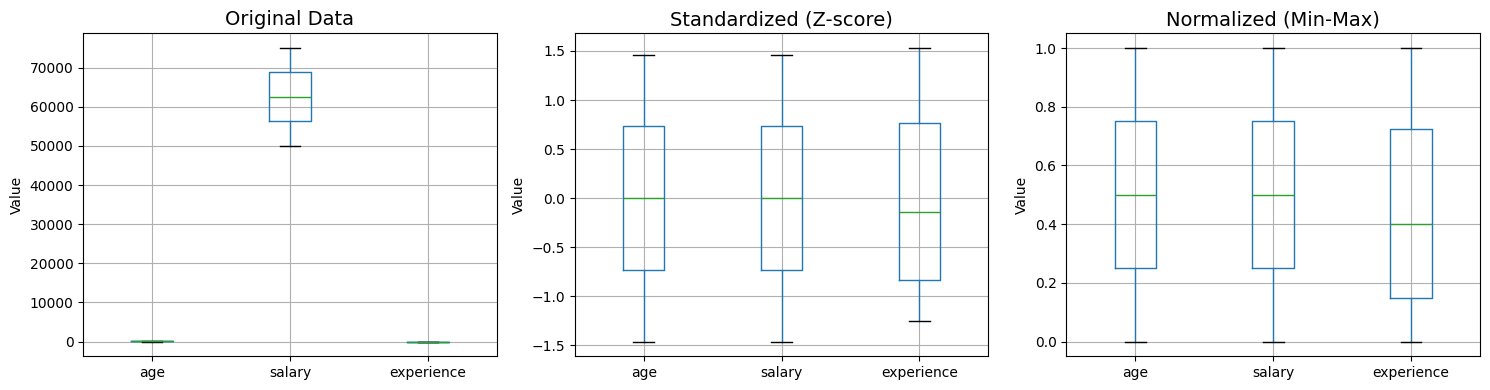

Notice how all features are now on comparable scales!


In [5]:
# Visualize scaling effects
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
data_scale.boxplot(ax=axes[0])
axes[0].set_title('Original Data', fontsize=14)
axes[0].set_ylabel('Value')

# Standardized
data_standardized.boxplot(ax=axes[1])
axes[1].set_title('Standardized (Z-score)', fontsize=14)
axes[1].set_ylabel('Value')

# Normalized
data_normalized.boxplot(ax=axes[2])
axes[2].set_title('Normalized (Min-Max)', fontsize=14)
axes[2].set_ylabel('Value')

plt.tight_layout()
plt.show()

print("Notice how all features are now on comparable scales!")

## 3. Encoding Categorical Variables

### Methods:
1. **Label Encoding:** Convert to integers (0, 1, 2, ...)
   - Use for: Ordinal data (low, medium, high)
   - Problem: Implies ordering

2. **One-Hot Encoding:** Create binary columns
   - Use for: Nominal data (colors, countries)
   - Problem: High dimensionality

3. **Target Encoding:** Replace with target mean
   - Use for: High cardinality features
   - Problem: Can cause overfitting

In [6]:
# Sample categorical data
data_cat = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'red', 'blue', 'green'],
    'size': ['small', 'medium', 'large', 'medium', 'small', 'large'],
    'price': [10, 20, 30, 15, 12, 35]
})

print("Original Categorical Data:")
print(data_cat)

# Label Encoding
le = LabelEncoder()
data_cat['color_encoded'] = le.fit_transform(data_cat['color'])
print("\nLabel Encoding (color):")
print(data_cat[['color', 'color_encoded']])
print(f"Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-Hot Encoding
data_onehot = pd.get_dummies(data_cat, columns=['color', 'size'], prefix=['color', 'size'])
print("\nOne-Hot Encoding:")
print(data_onehot)

Original Categorical Data:
   color    size  price
0    red   small     10
1   blue  medium     20
2  green   large     30
3    red  medium     15
4   blue   small     12
5  green   large     35

Label Encoding (color):
   color  color_encoded
0    red              2
1   blue              0
2  green              1
3    red              2
4   blue              0
5  green              1
Mapping: {'blue': 0, 'green': 1, 'red': 2}

One-Hot Encoding:
   price  color_encoded  color_blue  color_green  color_red  size_large  \
0     10              2       False        False       True       False   
1     20              0        True        False      False       False   
2     30              1       False         True      False        True   
3     15              2       False        False       True       False   
4     12              0        True        False      False       False   
5     35              1       False         True      False        True   

   size_medium  size_sma

## 4. Feature Selection

### Why Select Features?
- Reduce overfitting
- Improve model performance
- Reduce training time
- Improve interpretability

### Methods:
1. **Correlation Analysis:** Remove highly correlated features
2. **Variance Threshold:** Remove low-variance features
3. **Feature Importance:** Use model-based importance
4. **Recursive Feature Elimination:** Iteratively remove features

In [ ]:
# Create sample dataset
np.random.seed(42)
n_samples = 100
data_features = pd.DataFrame({
    'feature1': np.random.randn(n_samples),
    'feature2': np.random.randn(n_samples),
    'feature3': np.random.randn(n_samples) * 0.01,  # Low variance
    'target': np.random.randint(0, 2, n_samples)
})

# Add correlated feature
data_features['feature4'] = data_features['feature1'] * 2 + np.random.randn(n_samples) * 0.1

# Correlation matrix
correlation_matrix = data_features.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

print("\nHighly Correlated Features (>0.9):")
high_corr = np.where(np.abs(correlation_matrix) > 0.9)
high_corr_list = [(correlation_matrix.index[x], correlation_matrix.columns[y], correlation_matrix.iloc[x, y])
                  for x, y in zip(*high_corr) if x != y and x < y]
for feat1, feat2, corr in high_corr_list:
    print(f"  {feat1} <-> {feat2}: {corr:.3f}")

## 5. Feature Engineering

### Creating New Features:
1. **Polynomial Features:** x² , x³, x*y
2. **Binning:** Convert continuous to categorical
3. **Date Features:** Extract year, month, day, weekday
4. **Text Features:** Length, word count, sentiment
5. **Domain-Specific:** Based on problem knowledge

In [ ]:
# Example: House price prediction
house_data = pd.DataFrame({
    'area_sqft': [1000, 1500, 2000, 2500, 3000],
    'bedrooms': [2, 3, 3, 4, 4],
    'bathrooms': [1, 2, 2, 3, 3],
    'year_built': [1990, 2000, 2010, 2015, 2020],
    'price': [200000, 300000, 400000, 500000, 600000]
})

print("Original Features:")
print(house_data)

# Feature Engineering
house_data['price_per_sqft'] = house_data['price'] / house_data['area_sqft']
house_data['rooms_total'] = house_data['bedrooms'] + house_data['bathrooms']
house_data['age'] = 2026 - house_data['year_built']
house_data['area_squared'] = house_data['area_sqft'] ** 2
house_data['bed_bath_ratio'] = house_data['bedrooms'] / house_data['bathrooms']

print("\nWith Engineered Features:")
print(house_data)

## 6. Complete Preprocessing Pipeline

Let's put it all together!

In [6]:
# Load sample dataset (Titanic-like)
data_complete = pd.DataFrame({
    'age': [22, 38, 26, 35, np.nan, 54, 2, 27, 14, 4],
    'fare': [7.25, 71.28, 7.92, 53.10, 8.05, 51.86, 21.08, 11.13, 30.07, 16.70],
    'sex': ['male', 'female', 'female', 'female', 'male', 'male', 'male', 'male', 'female', 'female'],
    'class': ['3rd', '1st', '3rd', '1st', '3rd', '1st', '3rd', '3rd', '2nd', '3rd'],
    'survived': [0, 1, 1, 1, 0, 0, 0, 0, 1, 1]
})

print("Original Dataset:")
print(data_complete)
print(f"\nMissing values: {data_complete.isnull().sum().sum()}")

# Step 1: Handle missing values
data_complete['age'].fillna(data_complete['age'].median(), inplace=True)

# Step 2: Feature engineering
data_complete['age_group'] = pd.cut(data_complete['age'], bins=[0, 12, 18, 60, 100], 
                                     labels=['child', 'teen', 'adult', 'senior'])
data_complete['fare_per_age'] = data_complete['fare'] / (data_complete['age'] + 1)

# Step 3: Encode categorical
data_complete = pd.get_dummies(data_complete, columns=['sex', 'class', 'age_group'], drop_first=True)

# Step 4: Scale numerical features
scaler = StandardScaler()
numerical_cols = ['age', 'fare', 'fare_per_age']
data_complete[numerical_cols] = scaler.fit_transform(data_complete[numerical_cols])

print("\nAfter Complete Preprocessing:")
print(data_complete)
print(f"\nFinal shape: {data_complete.shape}")
print(f"Features: {data_complete.columns.tolist()}")

Original Dataset:
    age   fare     sex class  survived
0  22.0   7.25    male   3rd         0
1  38.0  71.28  female   1st         1
2  26.0   7.92  female   3rd         1
3  35.0  53.10  female   1st         1
4   NaN   8.05    male   3rd         0
5  54.0  51.86    male   1st         0
6   2.0  21.08    male   3rd         0
7  27.0  11.13    male   3rd         0
8  14.0  30.07  female   2nd         1
9   4.0  16.70  female   3rd         1

Missing values: 1

After Complete Preprocessing:
        age      fare  survived  fare_per_age  sex_male  class_2nd  class_3rd  \
0 -0.170020 -0.943087         0     -0.812588      True      False       True   
1  0.850102  1.989120         1     -0.064505     False      False      False   
2  0.085010 -0.912405         1     -0.823412     False      False       True   
3  0.658829  1.156580         1     -0.238950     False      False      False   
4       NaN -0.906452         0           NaN      True      False       True   
5  1.870225  1.09

/var/folders/20/z8cs1fd56xg91ycftn6fzq640000gn/T/ipykernel_49478/691789764.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data_complete['age'].fillna(data_complete['age'].median(), inplace=True)


## 7. Key Takeaways

### Data Preprocessing:
1. **Missing values** must be handled before training
2. **Feature scaling** improves convergence and performance
3. **Categorical encoding** is essential for ML models
4. **Feature selection** reduces overfitting and complexity

### Feature Engineering:
5. **Domain knowledge** is crucial for creating good features
6. **Polynomial features** can capture non-linear relationships
7. **Interaction features** reveal relationships between variables
8. **Always validate** new features improve model performance

### Best Practices:
9. **Fit on training data only**, then transform test data
10. **Document** all preprocessing steps for reproducibility
11. **Visualize** data before and after preprocessing
12. **Iterate** - preprocessing is an iterative process

## Next Steps (L7)
- Learn model evaluation metrics
- Understand cross-validation
- Handle imbalanced datasets

## References
- Scikit-learn Preprocessing: https://scikit-learn.org/stable/modules/preprocessing.html
- Feature Engineering Book: https://www.oreilly.com/library/view/feature-engineering-for/9781491953235/
- Pandas Documentation: https://pandas.pydata.org/docs/

---

## 🎯 Key Takeaways

**Relevant UoA Courses:** COMPSCI 761, COMPSCI 762

1. Normalization: (x - mean) / std brings features to similar scales
2. Min-max scaling: (x - min) / (max - min) maps to [0, 1]
3. Feature engineering creates new informative features from raw data
4. Handle missing data: imputation, deletion, or special encoding
5. Data augmentation artificially increases training data (rotation, flip, crop)

---

## 📚 Exam Preparation Guide

### Essential Concepts for Exams

- Know when to use normalization vs min-max scaling
- Calculate normalized value: given x=10, mean=5, std=2
- Understand why feature scaling improves gradient descent convergence
- Explain different missing data strategies and their trade-offs
- Common question: Why normalize before training neural networks?

### Common Mistakes to Avoid

- ❌ Normalizing test data with test statistics (should use training stats)
- ❌ Applying data augmentation to test set
- ❌ Not handling missing data before training

### Practice Problems

1. Given data [1, 2, 3, 4, 5], calculate normalized values
2. Why does unnormalized data cause slow training?
3. List 3 data augmentation techniques for images

### How This Helps Your UoA Courses

**COMPSCI 761, COMPSCI 762:**
- Provides hands-on implementation of theoretical concepts
- Practice problems similar to exam questions
- Reinforces lecture material with code examples
- Helps build intuition for complex topics

### Study Tips

1. **Understand, Don't Memorize**: Focus on why, not just what
2. **Practice Calculations**: Work through problems by hand
3. **Connect to Theory**: Link code to mathematical formulations
4. **Teach Others**: Explaining concepts solidifies understanding
5. **Review Regularly**: Spaced repetition improves retention

### Exam Question Types

- **Conceptual**: Explain why/how something works
- **Calculation**: Compute outputs, gradients, shapes
- **Comparison**: Compare approaches, trade-offs
- **Application**: Design solution for given problem
- **Debugging**: Identify and fix issues

---


---

## Learning Progress Tracker

Use this section to track your learning progress for this lesson.

### Completion Status
- [ ] Lesson completed
- [ ] All code cells executed successfully
- [ ] Understood all key concepts
- [ ] Completed practice exercises (if any)

### Dates
- **First Completed:** ____/____/____
- **Last Reviewed:** ____/____/____
- **Next Review:** ____/____/____ (Recommended: 1 week, 1 month, 3 months)

### Understanding Level
Rate your understanding (1-5): _____ / 5

- 1 = Need to review completely
- 2 = Understood basics, need more practice
- 3 = Good understanding, minor gaps
- 4 = Strong understanding, can explain to others
- 5 = Mastered, can apply in projects

### Notes & Reflections
```
Write your notes here:
- What concepts were challenging?
- What was interesting or surprising?
- How can you apply this in projects?
- Questions to explore further?




```

### Key Concepts to Remember (B06)
- [ ] Feature scaling and normalization
- [ ] Handling missing data
- [ ] Feature engineering techniques
- [ ] Data augmentation

---